In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
print("All libraries loaded successfully!")

All libraries loaded successfully!


In [19]:
df = pd.read_csv(r'C:\Users\LENOVO\Downloads\netflix_titles.csv')


In [20]:
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,25-Sep-21,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,24-Sep-21,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,24-Sep-21,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [21]:
# First rows
df.head()

# Shape
df.shape

# Info
df.info()

# Data types
df.dtypes

# Columns
df.columns

# Check unique values for key columns
df.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


show_id         8807
type               2
title           8804
director        4528
cast            7692
country          748
date_added      1767
release_year      74
rating            17
duration         220
listed_in        514
description     8775
dtype: int64

In [22]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [23]:
# Check percentage of missing values
(df.isnull().sum() / len(df)) * 100

show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64

In [25]:
# Fill categorical columns with a placeholder
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

# Fill columns with very few missing values using mode
df['date_added'] = df['date_added'].fillna(df['date_added'].mode()[0])
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df['duration'] = df['duration'].fillna(df['duration'].mode()[0])

# Verify
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [26]:
rows_before = len(df)
print(rows_before)

8807


In [27]:
# Check for duplicate rows
duplicates = df.duplicated().sum()
print("Number of Duplicate Rows:", duplicates)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Verify duplicates have been removed
print("Remaining Duplicate Rows:", df.duplicated().sum())

# Check dataset shape after removing duplicates
print("Dataset Shape:", df.shape)

Number of Duplicate Rows: 0
Remaining Duplicate Rows: 0
Dataset Shape: (8807, 12)


In [28]:
# Standardize column names
df.columns = df.columns.str.lower().str.strip()

# Standardize text columns
df['type'] = df['type'].str.lower().str.strip()

# Convert date column to datetime format
df['date_added'] = pd.to_datetime(df['date_added'])

# Verify changes
print(df.columns)
print(df.dtypes)

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')
show_id                 object
type                    object
title                   object
director                object
cast                    object
country                 object
date_added      datetime64[ns]
release_year             int64
rating                  object
duration                object
listed_in               object
description             object
dtype: object


In [ ]:
# Check unique values in categorical columns
print("Unique Ratings:")
print(df['rating'].unique())

print("\nUnique Types:")
print(df['type'].unique())

# Summary statistics for numerical columns
print("\nDescriptive Statistics:")
print(df.describe())

# Include all columns
print("\nFull Dataset Summary:")
print(df.describe(include='all'))

## ✅ Cleaning Summary

| Issue | Action |
|--------|--------|
| Missing Values | Filled missing values in `director`, `cast`, and `country` with "Unknown"; imputed `date_added`, `rating`, and `duration` using mode |
| Duplicates | Identified and removed duplicate records using `drop_duplicates()` |
| Invalid Entries | Checked unique values and corrected inconsistencies in categorical data |
| Standardization | Converted column names and text values to lowercase; transformed `date_added` to datetime format |

In [30]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [31]:
df['type'].value_counts()

movie      6131
tv show    2676
Name: type, dtype: int64

In [32]:
df['year_added'] = df['date_added'].dt.year
df['year_added'].value_counts().sort_index()

2008       2
2009       2
2010       1
2011      13
2012       3
2013      11
2014      24
2015      82
2016     429
2017    1188
2018    1649
2019    2016
2020    1889
2021    1498
Name: year_added, dtype: int64

In [33]:
df['country'].value_counts().head(10)


United States     2818
India              972
Unknown            831
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Name: country, dtype: int64

In [35]:
df['rating'].value_counts()

TV-MA       3211
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: rating, dtype: int64

In [36]:
df['listed_in'].value_counts().head(10)

Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            220
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: listed_in, dtype: int64

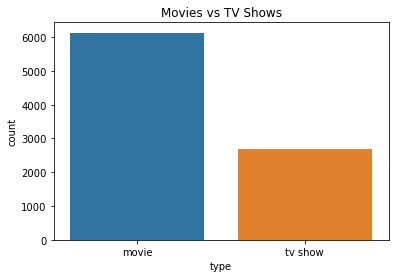

In [37]:
sns.countplot(x='type', data=df)
plt.title('Movies vs TV Shows')
plt.show()

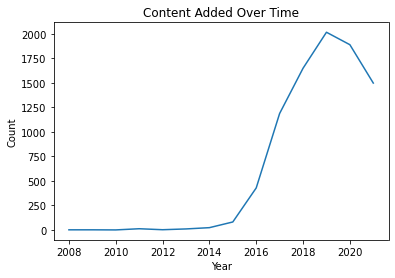

In [39]:
df['year_added'].value_counts().sort_index().plot()
plt.title('Content Added Over Time')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()


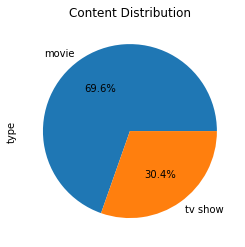

In [40]:
df['type'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Content Distribution')
plt.show()

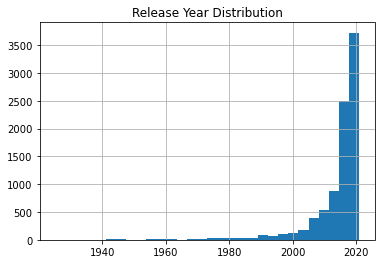

In [41]:
df['release_year'].hist(bins=30)
plt.title('Release Year Distribution')
plt.show()

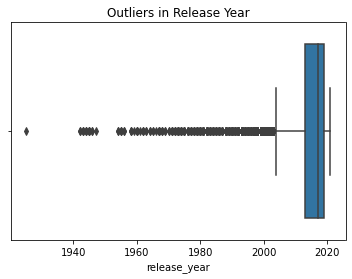

In [42]:
sns.boxplot(x=df['release_year'])
plt.title('Outliers in Release Year')
plt.show()

### ✅ Insight 1: Movies dominate Netflix content
The bar chart above shows that movies (over 6000 titles) significantly outnumber TV shows (around 2700 titles).  
This indicates that Netflix focuses more on movie content compared to TV series.

### ✅ Insight 2: Rapid growth in content after 2015
The line chart above shows a sharp increase in the number of titles added after 2015, peaking around 2019–2020.  
This suggests that Netflix expanded its content library aggressively during this period.


### ✅ Insight 3: Movies account for nearly 70% of all content
The pie chart above shows that movies make up about 69.6% of the dataset, while TV shows account for only 30.4%.  
This reinforces the dominance of movies on the platform.

### ✅ Insight 4: Most content is recent (post-2000)
The histogram above shows that the majority of Netflix content was released after the year 2000, with a strong concentration between 2015 and 2020.  
This indicates that Netflix focuses more on modern and recently produced content.


### ✅ Insight 5: Presence of older content as outliers
The boxplot above reveals that most release years are concentrated in recent decades, while a few very old titles appear as outliers.  
This suggests that although Netflix primarily hosts modern content, it also includes some classic or older titles.

In [46]:
df.to_csv('cleaned_netflix.csv', index=False)